In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier , plot_tree , export_text            

In [3]:
df = pd.read_excel("Rework_cummulative_brand_data_cluster.xlsx")
df

,Brand,Quantity ( Grams),MRP,Price,Price/100 Grams,Discount (%),Cluster,projected_rating_count
0,Happilo,500.0,265,79,15.800000,70,2,21235
1,Happilo,500.0,225,110,22.000000,51,2,4369
2,Happilo,250.0,125,59,23.600000,52,2,2095
3,Happilo,250.0,125,59,23.600000,52,2,2095
4,Happilo,250.0,125,61,24.400000,51,2,3009
...,...,...,...,...,...,...,...,...
443,The Whole Truth,210.0,1199,1009,480.476190,16,0,144
444,The Whole Truth,210.0,1199,1009,480.476190,16,0,144
445,Yogabar,750.0,4999,3818,509.066667,23,1,752
446,Yogabar,750.0,4999,3818,509.066667,23,1,752


In [5]:
df.columns = df.columns.str.strip()
df.columns

Index(['Brand', 'Quantity ( Grams)', 'MRP', 'Price', 'Price/100 Grams',
       'Discount (%)', 'Cluster', 'projected_rating_count'],
      dtype='object')

In [6]:
features = ['Quantity ( Grams)','Price']
target = 'Cluster'

In [9]:
X = df[features]
y = df[target]
X = X.fillna(X.median())
y = y.fillna(y.mode()[0])

In [10]:
clf = DecisionTreeClassifier(max_depth=4,random_state=42)
clf.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
tree_rules = export_text(clf,feature_names=features)
print(tree_rules)

|--- Price <= 488.50
|   |--- Quantity ( Grams) <= 550.00
|   |   |--- Quantity ( Grams) <= 402.50
|   |   |   |--- class: 2
|   |   |--- Quantity ( Grams) >  402.50
|   |   |   |--- Price <= 350.50
|   |   |   |   |--- class: 2
|   |   |   |--- Price >  350.50
|   |   |   |   |--- class: 0
|   |--- Quantity ( Grams) >  550.00
|   |   |--- class: 0
|--- Price >  488.50
|   |--- Price <= 1798.00
|   |   |--- Quantity ( Grams) <= 205.50
|   |   |   |--- class: 2
|   |   |--- Quantity ( Grams) >  205.50
|   |   |   |--- Price <= 531.50
|   |   |   |   |--- class: 0
|   |   |   |--- Price >  531.50
|   |   |   |   |--- class: 0
|   |--- Price >  1798.00
|   |   |--- Quantity ( Grams) <= 1502.50
|   |   |   |--- class: 1
|   |   |--- Quantity ( Grams) >  1502.50
|   |   |   |--- class: 3



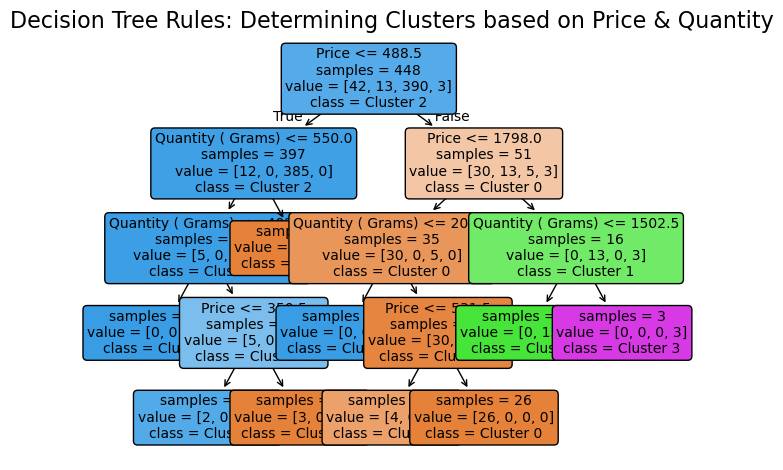

In [13]:
plot_tree(clf, 
              feature_names=features,  
              class_names=[f"Cluster {c}" for c in sorted(y.unique())], # Name the outputs
              filled=True,      # Color nodes by majority class
              rounded=True,     # Rounded boxes
              impurity=False,   # Hide Gini impurity to keep it cleaner to read
              fontsize=10)

plt.title("Decision Tree Rules: Determining Clusters based on Price & Quantity", fontsize=16)
plt.tight_layout()